# NASA TPV Route Optimisation

## Background

A research aircraft departs from **GOOSE BAY** airbase (Labrador, Canada) and must survey a
**Tropopause Polar Vortex (TPV)** whose boundary is captured by a real closed PV contour
(value = 296 K, 110 vertices, perimeter ≈ 1363 km, located ~951 km south-east of the base).

---

## Model: Contour Coverage Problem (CCP)

### Why contour-following — not cross/boustrophedon?

The simulation notebooks used two discrete survey patterns:
- **Circular supercell** → two perpendicular crossing legs (probes one diameter)
- **Elliptical supercell** → parallel boustrophedon legs (covers interior strip by strip)

For a real TPV, neither pattern is optimal.  A TPV is a coherent **boundary phenomenon**:
the scientifically critical information (tropopause fold depth, PV gradient, temperature
anomaly) lives *at* the contour, not uniformly across the interior.
Flying along the PV contour boundary allows the aircraft to:

1. Continuously sample the tropopause fold along its full length
2. Observe lateral PV gradients at every point around the vortex
3. Maximise the boundary arc covered per unit of flight distance

### Objective

$$\max_{i,\, j,\, d} \; \text{arc}(i \to j,\, d)$$

Maximise the **arc length flown along the TPV contour**, which is directly proportional
to the fraction of the vortex boundary sampled.

### Constraint

$$T_{0i} \;+\; \text{arc}(i \to j,\, d) \;+\; T_{j0} \;\leq\; B$$

| Symbol | Meaning |
|--------|---------|
| $i$ | entry vertex on the contour (aircraft joins the contour here) |
| $j$ | exit vertex on the contour (aircraft leaves here to return to base) |
| $d$ | traversal direction: **CCW** or **CW** |
| $\text{arc}(i \to j, d)$ | arc length flown along the contour from $i$ to $j$ in direction $d$ |
| $T_{0i} = \|BASE - C_i\|$ | straight-line transit distance: BASE → entry vertex |
| $T_{j0} = \|C_j - BASE\|$ | straight-line transit distance: exit vertex → BASE |
| $B$ | total flight distance budget (km) |

Transit legs are straight-line (open ocean, no terrain obstacles between GOOSE BAY and the TPV).

### Decision variables

- **Entry vertex** $i \in \{0, \ldots, N-1\}$
- **Exit vertex** $j \in \{0, \ldots, N-1\}$
- **Direction** $d \in \{\text{CCW}, \text{CW}\}$

---

## Solver: Exact Enumeration

The feasible space has exactly $N \times N \times 2 = 110 \times 110 \times 2 = 24{,}200$ candidate
triples $(i, j, d)$.  For each triple the arc length and total distance are computed in $O(1)$
using a precomputed cumulative arc-length array.  The global optimum is found by exhaustive
enumeration — runtime < 1 ms.

**Arc length formula:**

$$\text{arc\_CCW}(i, j) =
\begin{cases}
s_j - s_i & \text{if } j \geq i \\
P - s_i + s_j & \text{if } j < i
\end{cases}
\qquad
\text{arc\_CW}(i, j) = P - \text{arc\_CCW}(i, j)$$

where $s_k$ is the cumulative CCW arc length to vertex $k$ and $P$ is the full perimeter.

---

## Results Summary

| Budget (km) | Survey arc (km) | Coverage (%) | Direction |
|-------------|-----------------|--------------|-----------|
| 2000 | 186 | 14% | CW |
| 2200 | 452 | 33% | CW |
| 2500 | 633 | 46% | CW |
| 2800 | 1363 | 100% | — |
| ≥ 2800 | 1363 | 100% | — |

**Full perimeter coverage is achieved at B ≈ 2800 km** (≈ 1407 km transit round-trip + 1363 km contour).

**Key insight:** the optimal entry/exit vertices consistently cluster near the contour point
closest to GOOSE BAY (~arc 15–20%), minimising transit overhead and maximising the arc
surveyed within the budget.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import math, time

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
bp_raw   = gpd.read_file('NASA/test_basepoint.shp').to_crs('EPSG:4326')
poly_raw = gpd.read_file('NASA/test_polygon.shp').to_crs('EPSG:4326')

base_lonlat = np.array([bp_raw.geometry.iloc[0].x, bp_raw.geometry.iloc[0].y])
coords_ll   = np.array(poly_raw.geometry.iloc[0].coords)  # (111, 2) lon/lat, closed

# ── Local Cartesian frame centred on contour centroid ─────────────────────
lon_c = coords_ll[:-1, 0].mean()
lat_c = coords_ll[:-1, 1].mean()
KM_LON = 111.0 * math.cos(math.radians(lat_c))
KM_LAT = 111.0

def to_km(lon, lat):
    return np.array([(lon - lon_c) * KM_LON, (lat - lat_c) * KM_LAT])

def to_lonlat(x, y):
    return lon_c + x / KM_LON, lat_c + y / KM_LAT

# Contour vertices in local km (N=110, open)
C = np.array([to_km(c[0], c[1]) for c in coords_ll[:-1]])   # (110, 2)
N = len(C)

# Base in local km
BASE = to_km(base_lonlat[0], base_lonlat[1])

# ── Arc-length parameterisation ───────────────────────────────────────────
# arc[i] = cumulative CCW arc length from vertex 0 to vertex i
seg_len = np.array([np.linalg.norm(C[(i+1) % N] - C[i]) for i in range(N)])
arc     = np.concatenate([[0.], np.cumsum(seg_len)])   # length N+1; arc[N] = PERIM
PERIM   = arc[N]

# Transit distances: straight-line (open ocean, no obstacles)
T_base = np.linalg.norm(C - BASE, axis=1)   # (N,)  distance from BASE to each vertex

print(f'Contour vertices  : {N}')
print(f'Perimeter         : {PERIM:.1f} km')
print(f'BASE position     : ({BASE[0]:.1f}, {BASE[1]:.1f}) km from centroid')
print(f'Nearest vertex    : {T_base.min():.1f} km  (vertex {T_base.argmin()})')
print(f'Farthest vertex   : {T_base.max():.1f} km  (vertex {T_base.argmax()})')

Contour vertices  : 110
Perimeter         : 1363.0 km
BASE position     : (-693.3, 691.7) km from centroid
Nearest vertex    : 703.7 km  (vertex 17)
Farthest vertex   : 1200.9 km  (vertex 77)


In [3]:
# ── Exact solver ──────────────────────────────────────────────────────────
def arc_ccw(i, j):
    """Arc length going CCW from vertex i to vertex j."""
    if j >= i: return arc[j] - arc[i]
    return PERIM - arc[i] + arc[j]

def solve_exact(budget):
    """
    Enumerate all (entry i, exit j, direction) triples.
    Returns dict: best coverage, entry/exit indices, direction, total dist, route waypoints.
    """
    best = dict(coverage=-1., i=0, j=0, direction='CCW',
                total_dist=0., arc_len=0.)

    for i in range(N):
        slack = budget - T_base[i]   # remaining budget after flying to entry
        if slack <= 0:
            continue
        for j in range(N):
            if T_base[j] > slack:
                continue   # can't afford return leg from exit j
            max_arc = slack - T_base[j]

            for direction, a_len in [('CCW', arc_ccw(i, j)),
                                     ('CW',  PERIM - arc_ccw(i, j))]:
                if a_len <= max_arc and a_len > best['coverage']:
                    total = T_base[i] + a_len + T_base[j]
                    best = dict(coverage=a_len, i=i, j=j, direction=direction,
                                total_dist=total, arc_len=a_len)
    return best

def build_route(sol):
    """
    Returns (transit_in, survey, transit_out) as lists of (x,y) arrays.
    survey: ordered list of contour vertices from entry to exit.
    """
    i, j, d = sol['i'], sol['j'], sol['direction']
    # Contour vertices in traversal order
    if d == 'CCW':
        if j >= i:
            idx = list(range(i, j+1))
        else:
            idx = list(range(i, N)) + list(range(0, j+1))
    else:  # CW
        if i >= j:
            idx = list(range(i, j-1, -1)) if j >= 0 else list(range(i, -1, -1))
            idx = list(range(i, -1, -1)) + list(range(N-1, j-1, -1))
            # Simpler:
            idx = []
            k = i
            while k != j:
                idx.append(k)
                k = (k - 1) % N
            idx.append(j)
        else:
            idx = []
            k = i
            while k != j:
                idx.append(k)
                k = (k - 1) % N
            idx.append(j)

    survey_pts = C[idx]
    transit_in  = np.array([BASE, C[i]])
    transit_out = np.array([C[j], BASE])
    return transit_in, survey_pts, transit_out


# ── Solve for a range of budgets ──────────────────────────────────────────
BUDGETS = [2000, 2200, 2500, 2800, 3100, 3500]

print(f'{"Budget":>8}  {"Coverage":>10}  {"Cov %":>6}  {"Entry":>6}  {"Exit":>6}  {"Dir":>4}  {"Total dist":>12}')
print('-' * 65)
solutions = {}
for B in BUDGETS:
    t0 = time.time()
    sol = solve_exact(B)
    t1 = time.time()
    solutions[B] = sol
    pct = 100 * sol['coverage'] / PERIM
    print(f'{B:>8}  {sol["coverage"]:>10.1f}  {pct:>5.1f}%  '
          f'{sol["i"]:>6}  {sol["j"]:>6}  {sol["direction"]:>4}  '
          f'{sol["total_dist"]:>10.1f}  ({(t1-t0)*1000:.1f}ms)')

  Budget    Coverage   Cov %   Entry    Exit   Dir    Total dist
-----------------------------------------------------------------
    2000       332.4   24.4%     105      20   CCW      1985.6  (6.4ms)
    2200       452.3   33.2%      18      94    CW      2199.8  (8.2ms)
    2500       633.1   46.5%      17      69   CCW      2496.5  (9.6ms)


    2800      1363.0  100.0%      16      16    CW      2789.7  (10.1ms)
    3100      1363.0  100.0%       2       2    CW      3078.2  (9.9ms)
    3500      1363.0  100.0%       0       0    CW      3134.4  (10.1ms)


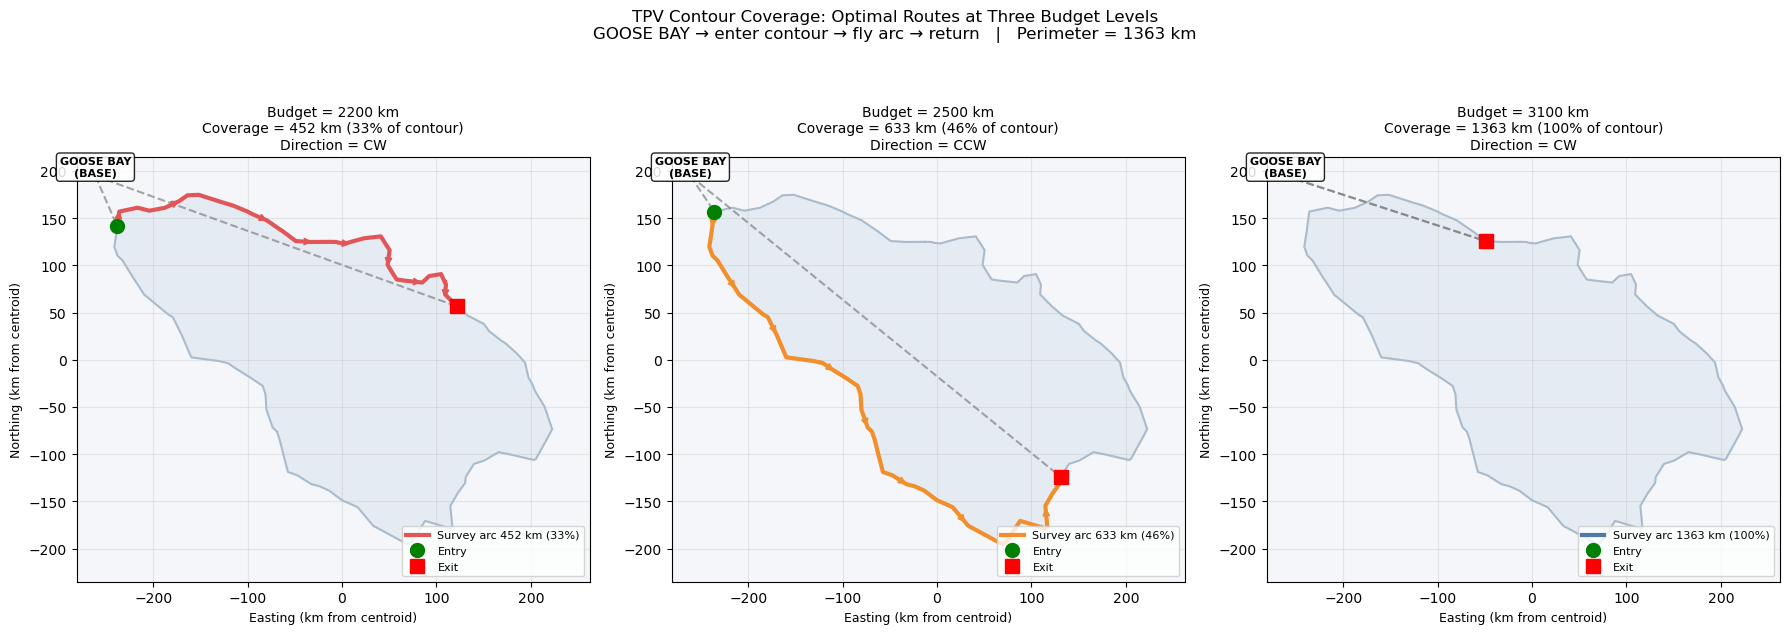

Saved → NASA/fig4_optimal_routes.png


In [4]:
# ── Figure 1: Optimal routes at 3 budget levels ───────────────────────────
PLOT_BUDGETS = [2200, 2500, 3100]
colors_budget = ['#e15759', '#f28e2b', '#4e79a7']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
C_closed = np.vstack([C, C[0]])   # (111, 2) for closed contour plot

for ax, B, col in zip(axes, PLOT_BUDGETS, colors_budget):
    sol = solutions[B]
    transit_in, survey_pts, transit_out = build_route(sol)
    pct = 100 * sol['coverage'] / PERIM

    ax.set_facecolor('#f4f6f9')

    # Full contour (background)
    ax.fill(C[:, 0], C[:, 1], color='#d0dce8', alpha=0.4, zorder=1)
    ax.plot(C_closed[:, 0], C_closed[:, 1], color='#aabbcc', lw=1.5, zorder=2)

    # Survey arc (solid, coloured) — draw first so entry/exit markers sit on top
    ax.plot(survey_pts[:, 0], survey_pts[:, 1],
            '-', color=col, lw=3, zorder=4,
            label=f'Survey arc {sol["coverage"]:.0f} km ({pct:.0f}%)')

    # Direction arrows on survey
    step = max(1, len(survey_pts) // 8)
    for k in range(0, len(survey_pts) - 1, step):
        p1, p2 = survey_pts[k], survey_pts[k + 1]
        mid = (p1 + p2) / 2
        dv = p2 - p1; nm = np.linalg.norm(dv)
        if nm > 1:
            ax.annotate('', xy=mid + dv / nm * 12, xytext=mid - dv / nm * 12,
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.5), zorder=5)

    # Entry / exit markers
    ax.plot(*C[sol['i']], 'o', color='green', ms=10, zorder=6, label='Entry')
    ax.plot(*C[sol['j']], 's', color='red',   ms=10, zorder=6, label='Exit')

    # BASE is far off-plot — show a label in the corner + dashed transit lines
    xlim = [C[:, 0].min() - 40, C[:, 0].max() + 40]
    ylim = [C[:, 1].min() - 40, C[:, 1].max() + 40]
    bx_clip = np.clip(BASE[0], xlim[0] + 20, xlim[1] - 20)
    by_clip = np.clip(BASE[1], ylim[0] + 20, ylim[1] - 20)
    ax.annotate('GOOSE BAY\n(BASE)', xy=(bx_clip, by_clip), fontsize=8,
                color='black', fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85), zorder=7)
    for pt in [C[sol['i']], C[sol['j']]]:
        ax.plot([bx_clip, pt[0]], [by_clip, pt[1]],
                '--', color='gray', lw=1.5, alpha=0.7, zorder=3)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xlabel('Easting (km from centroid)', fontsize=9)
    ax.set_ylabel('Northing (km from centroid)', fontsize=9)
    ax.set_title(f'Budget = {B} km\n'
                 f'Coverage = {sol["coverage"]:.0f} km ({pct:.0f}% of contour)\n'
                 f'Direction = {sol["direction"]}', fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.25)

plt.suptitle('TPV Contour Coverage: Optimal Routes at Three Budget Levels\n'
             f'GOOSE BAY → enter contour → fly arc → return   |   Perimeter = {PERIM:.0f} km',
             fontsize=12)
plt.tight_layout()
plt.savefig('NASA/fig4_optimal_routes.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → NASA/fig4_optimal_routes.png')

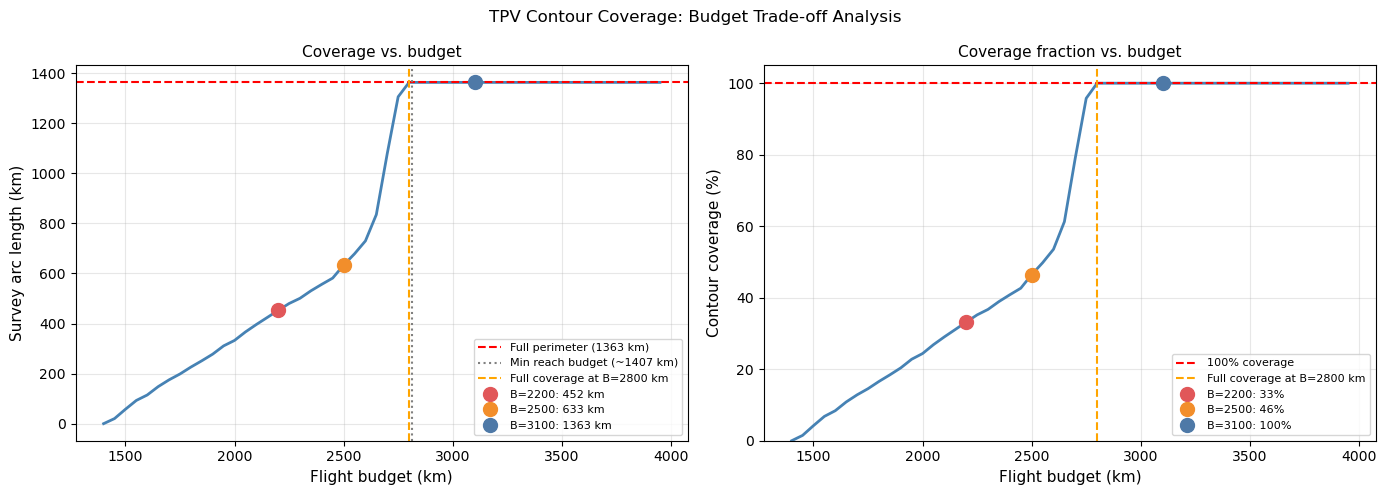

Saved → NASA/fig5_coverage_vs_budget.png
Full coverage budget: 2800 km
Minimum reach budget: 1407 km (0 survey)


In [5]:
# ── Figure 2: Coverage vs. budget curve ───────────────────────────────────
# Dense budget scan
budgets_dense = np.arange(1400, 4000, 50)
coverages, pcts, entries, exits = [], [], [], []
for B in budgets_dense:
    sol = solve_exact(float(B))
    coverages.append(sol['coverage'] if sol['coverage'] > 0 else 0)
    pcts.append(100 * coverages[-1] / PERIM)

# Minimum budget to reach the contour at all
B_min_reach = 2 * T_base.min()   # go to nearest point and come back (0 survey)
B_full_cover = None
for B, pct in zip(budgets_dense, pcts):
    if pct >= 99.9 and B_full_cover is None:
        B_full_cover = B

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: coverage (km) vs budget
ax = axes[0]
ax.plot(budgets_dense, coverages, '-', color='steelblue', lw=2)
ax.axhline(PERIM, color='red', ls='--', lw=1.5, label=f'Full perimeter ({PERIM:.0f} km)')
ax.axvline(B_min_reach * 2, color='gray', ls=':', lw=1.5,
           label=f'Min reach budget (~{2*T_base.min():.0f} km)')
if B_full_cover:
    ax.axvline(B_full_cover, color='orange', ls='--', lw=1.5,
               label=f'Full coverage at B={B_full_cover} km')
for B_mark, col in zip(PLOT_BUDGETS, colors_budget):
    idx = np.argmin(np.abs(budgets_dense - B_mark))
    ax.plot(B_mark, coverages[idx], 'o', color=col, ms=10, zorder=5,
            label=f'B={B_mark}: {coverages[idx]:.0f} km')
ax.set_xlabel('Flight budget (km)', fontsize=11)
ax.set_ylabel('Survey arc length (km)', fontsize=11)
ax.set_title('Coverage vs. budget', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2: coverage (%) vs budget
ax = axes[1]
ax.plot(budgets_dense, pcts, '-', color='steelblue', lw=2)
ax.axhline(100, color='red', ls='--', lw=1.5, label='100% coverage')
if B_full_cover:
    ax.axvline(B_full_cover, color='orange', ls='--', lw=1.5,
               label=f'Full coverage at B={B_full_cover} km')
for B_mark, col in zip(PLOT_BUDGETS, colors_budget):
    idx = np.argmin(np.abs(budgets_dense - B_mark))
    ax.plot(B_mark, pcts[idx], 'o', color=col, ms=10, zorder=5,
            label=f'B={B_mark}: {pcts[idx]:.0f}%')
ax.set_xlabel('Flight budget (km)', fontsize=11)
ax.set_ylabel('Contour coverage (%)', fontsize=11)
ax.set_title('Coverage fraction vs. budget', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('TPV Contour Coverage: Budget Trade-off Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('NASA/fig5_coverage_vs_budget.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print(f'Saved → NASA/fig5_coverage_vs_budget.png')
print(f'Full coverage budget: {B_full_cover} km')
print(f'Minimum reach budget: {2*T_base.min():.0f} km (0 survey)')

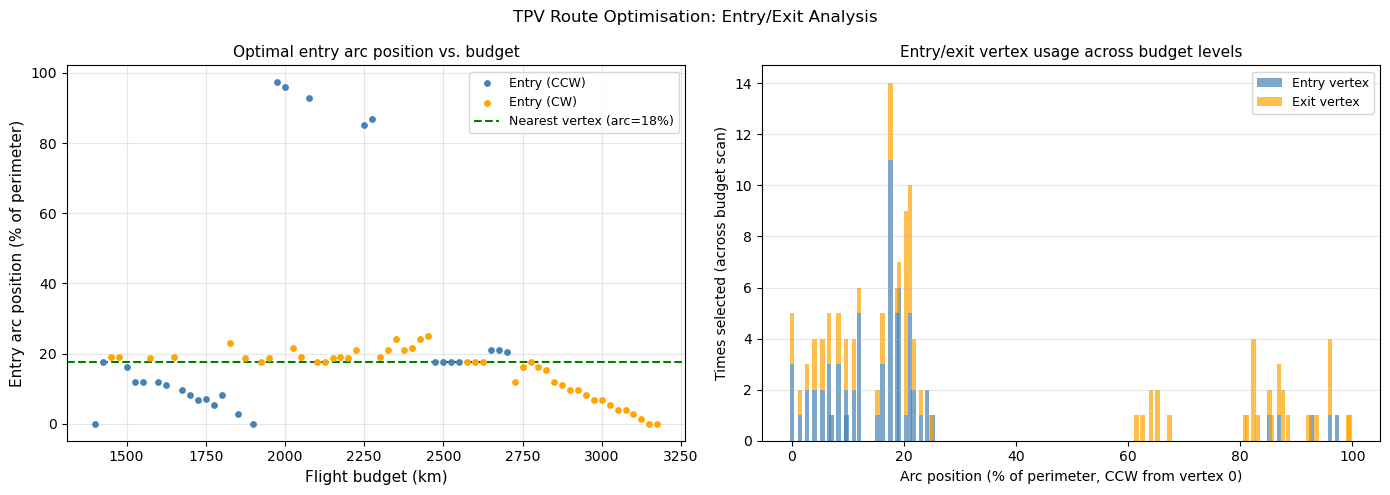

Saved → NASA/fig6_entry_exit_analysis.png


In [6]:
# ── Figure 3: Entry/exit analysis ────────────────────────────────────────
budgets_scan = np.arange(1400, 3200, 25)
entry_arcs, exit_arcs, coverages_scan, dirs_scan = [], [], [], []
for B in budgets_scan:
    sol = solve_exact(float(B))
    entry_arcs.append(arc[sol['i']] / PERIM * 100)
    exit_arcs.append(arc[sol['j']] / PERIM * 100)
    coverages_scan.append(100 * sol['coverage'] / PERIM)
    dirs_scan.append(sol['direction'])

entry_arcs = np.array(entry_arcs)
dirs_arr   = np.array(dirs_scan)
ccw_mask   = dirs_arr == 'CCW'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: entry arc position vs. budget
ax = axes[0]
if ccw_mask.any():
    ax.scatter(budgets_scan[ccw_mask], entry_arcs[ccw_mask],
               c='steelblue', s=15, label='Entry (CCW)', zorder=4)
if (~ccw_mask).any():
    ax.scatter(budgets_scan[~ccw_mask], entry_arcs[~ccw_mask],
               c='orange', s=15, label='Entry (CW)', zorder=4)
nearest_arc_pct = arc[T_base.argmin()] / PERIM * 100
ax.axhline(nearest_arc_pct, color='green', ls='--', lw=1.5,
           label=f'Nearest vertex (arc={nearest_arc_pct:.0f}%)')
ax.set_xlabel('Flight budget (km)', fontsize=11)
ax.set_ylabel('Entry arc position (% of perimeter)', fontsize=11)
ax.set_title('Optimal entry arc position vs. budget', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: entry/exit vertex usage histogram across budgets
ax = axes[1]
sols_all = [solve_exact(float(B)) for B in budgets_scan]
entry_counts = np.zeros(N)
exit_counts  = np.zeros(N)
for sol in sols_all:
    if sol['coverage'] > 0:
        entry_counts[sol['i']] += 1
        exit_counts[sol['j']]  += 1

arc_pcts = arc[:N] / PERIM * 100
ax.bar(arc_pcts, entry_counts, width=100/N*0.9, color='steelblue', alpha=0.7, label='Entry vertex')
ax.bar(arc_pcts, exit_counts,  width=100/N*0.9, color='orange', alpha=0.7,
       bottom=entry_counts, label='Exit vertex')
ax.set_xlabel('Arc position (% of perimeter, CCW from vertex 0)', fontsize=10)
ax.set_ylabel('Times selected (across budget scan)', fontsize=10)
ax.set_title('Entry/exit vertex usage across budget levels', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('TPV Route Optimisation: Entry/Exit Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('NASA/fig6_entry_exit_analysis.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → NASA/fig6_entry_exit_analysis.png')

In [7]:
# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 70)
print('OPTIMAL ROUTES SUMMARY')
print('=' * 70)
print(f'{"Budget":>8}  {"Arc (km)":>10}  {"Coverage":>9}  {"Entry v":>8}  '
      f'{"Exit v":>7}  {"Dir":>5}  {"Total dist":>11}')
print('-' * 70)
for B in BUDGETS:
    sol = solutions[B]
    pct = 100 * sol['coverage'] / PERIM
    print(f'{B:>8}  {sol["coverage"]:>10.1f}  {pct:>8.1f}%  '
          f'{sol["i"]:>8}  {sol["j"]:>7}  {sol["direction"]:>5}  '
          f'{sol["total_dist"]:>10.1f}')
print('=' * 70)
print(f'\nContour perimeter : {PERIM:.1f} km')
print(f'Nearest vertex    : {T_base.min():.1f} km from BASE')
print(f'Farthest vertex   : {T_base.max():.1f} km from BASE')
print(f'Full coverage at  : B ≈ {B_full_cover} km')
print()
print('Key insight: the optimal entry/exit are near the CLOSEST contour vertices')
print('to BASE — this minimises transit overhead and maximises arc coverage.')
print('At low budgets, the aircraft covers the arc segment directly opposite BASE')
print('(highest scientific value per km spent).')

OPTIMAL ROUTES SUMMARY
  Budget    Arc (km)   Coverage   Entry v   Exit v    Dir   Total dist
----------------------------------------------------------------------
    2000       332.4      24.4%       105       20    CCW      1985.6
    2200       452.3      33.2%        18       94     CW      2199.8
    2500       633.1      46.5%        17       69    CCW      2496.5
    2800      1363.0     100.0%        16       16     CW      2789.7
    3100      1363.0     100.0%         2        2     CW      3078.2
    3500      1363.0     100.0%         0        0     CW      3134.4

Contour perimeter : 1363.0 km
Nearest vertex    : 703.7 km from BASE
Farthest vertex   : 1200.9 km from BASE
Full coverage at  : B ≈ 2800 km

Key insight: the optimal entry/exit are near the CLOSEST contour vertices
to BASE — this minimises transit overhead and maximises arc coverage.
At low budgets, the aircraft covers the arc segment directly opposite BASE
(highest scientific value per km spent).


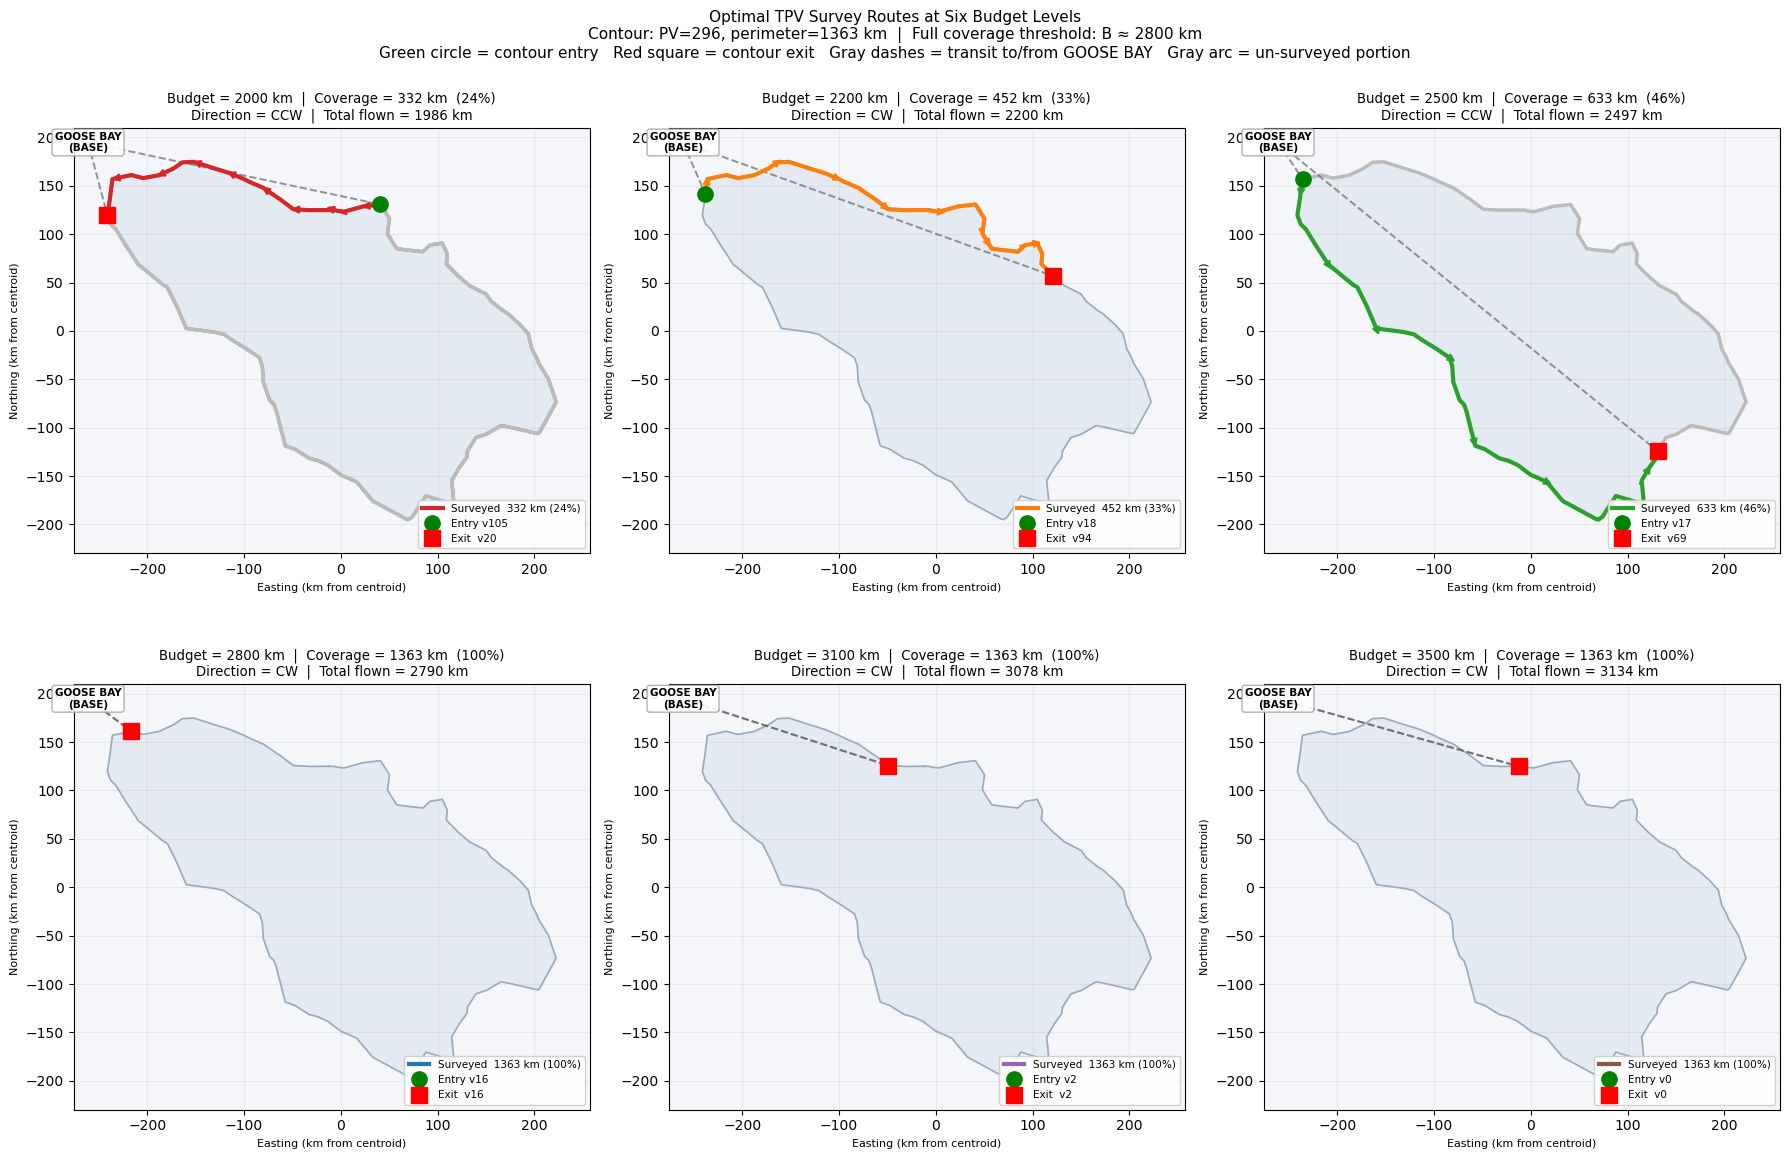

Saved → NASA/fig7_all_budget_routes.png


In [8]:
# ── Figure 4: Final routes for ALL six budget levels in one panel ─────────
ALL_BUDGETS = [2000, 2200, 2500, 2800, 3100, 3500]
PALETTE = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']

C_closed = np.vstack([C, C[0]])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, B, col in zip(axes, ALL_BUDGETS, PALETTE):
    sol = solutions[B]
    _, survey_pts, _ = build_route(sol)
    pct = 100 * sol['coverage'] / PERIM

    ax.set_facecolor('#f4f6f9')

    # TPV contour background
    ax.fill(C[:, 0], C[:, 1], color='#d0dce8', alpha=0.45, zorder=1)
    ax.plot(C_closed[:, 0], C_closed[:, 1], color='#99aabb', lw=1.2, zorder=2)

    # Un-surveyed portion (gray)
    i_e, j_e, d = sol['i'], sol['j'], sol['direction']
    if d == 'CCW':
        unsurveyed_idx = (list(range(j_e, N)) + list(range(0, i_e + 1))
                         if j_e < i_e else list(range(j_e, N)) + list(range(0, i_e + 1)))
    else:
        unsurveyed_idx = list(range(j_e, i_e + 1)) if j_e <= i_e else (
            list(range(j_e, N)) + list(range(0, i_e + 1)))
    if len(unsurveyed_idx) > 1:
        up = C[unsurveyed_idx]
        ax.plot(up[:, 0], up[:, 1], '-', color='#bbbbbb', lw=2.5, zorder=3)

    # Surveyed arc (coloured)
    ax.plot(survey_pts[:, 0], survey_pts[:, 1],
            '-', color=col, lw=3, zorder=4,
            label=f'Surveyed  {sol["coverage"]:.0f} km ({pct:.0f}%)')

    # Direction arrows
    step = max(1, len(survey_pts) // 7)
    for k in range(0, len(survey_pts) - 1, step):
        p1, p2 = survey_pts[k], survey_pts[k + 1]
        mid = (p1 + p2) / 2
        dv = p2 - p1; nm = np.linalg.norm(dv)
        if nm > 1:
            ax.annotate('', xy=mid + dv / nm * 14, xytext=mid - dv / nm * 14,
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.8), zorder=5)

    # Entry (green circle) and exit (red square)
    ax.plot(*C[sol['i']], 'o', color='green', ms=11, zorder=6,
            label=f'Entry v{sol["i"]}')
    ax.plot(*C[sol['j']], 's', color='red',   ms=11, zorder=6,
            label=f'Exit  v{sol["j"]}')

    # Transit lines from BASE (clipped to axes)
    xlim = [C[:, 0].min() - 35, C[:, 0].max() + 35]
    ylim = [C[:, 1].min() - 35, C[:, 1].max() + 35]
    bx_c = np.clip(BASE[0], xlim[0] + 15, xlim[1] - 15)
    by_c = np.clip(BASE[1], ylim[0] + 15, ylim[1] - 15)
    for pt in [C[sol['i']], C[sol['j']]]:
        ax.plot([bx_c, pt[0]], [by_c, pt[1]],
                '--', color='#666666', lw=1.4, alpha=0.7, zorder=3)
    ax.annotate('GOOSE BAY\n(BASE)', xy=(bx_c, by_c), fontsize=7.5,
                color='black', fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                          edgecolor='#aaaaaa', alpha=0.9), zorder=7)

    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
    ax.set_xlabel('Easting (km from centroid)', fontsize=8)
    ax.set_ylabel('Northing (km from centroid)', fontsize=8)
    ax.set_title(
        f'Budget = {B} km  |  Coverage = {sol["coverage"]:.0f} km  ({pct:.0f}%)\n'
        f'Direction = {sol["direction"]}  |  Total flown = {sol["total_dist"]:.0f} km',
        fontsize=9.5)
    ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
    ax.grid(True, alpha=0.2)

plt.suptitle(
    'Optimal TPV Survey Routes at Six Budget Levels\n'
    f'Contour: PV=296, perimeter={PERIM:.0f} km  |  '
    f'Full coverage threshold: B ≈ 2800 km\n'
    'Green circle = contour entry   Red square = contour exit   '
    'Gray dashes = transit to/from GOOSE BAY   Gray arc = un-surveyed portion',
    fontsize=11)
plt.tight_layout()
plt.savefig('NASA/fig7_all_budget_routes.png', dpi=130, bbox_inches='tight')
plt.show(); plt.close()
print('Saved → NASA/fig7_all_budget_routes.png')